# Angstrom Fire Index Calculation Using LDAS Forecast

Author: K. Su 

Date: 2026/09/13

In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("./monthly_ldas_2001_01.nc")

da_qair = ds['Qair_f_tavg'] / 1000
# ds['Psurf_f_tavg']
da_qair.attrs['units'] = 'kg/kg'

da_psurf = ds['Psurf_f_tavg']

def get_Pvapour_f_tavg(
        qair_f_tavg : xr.DataArray,
        psurf_f_tavg : xr.DataArray,
) -> xr.DataArray:
    da = (qair_f_tavg * psurf_f_tavg) / (0.622 + 0.378 * qair_f_tavg)
    da.attrs['units'] = 'Pa'
    da.attrs.update({'standard_name' : 'Pvapour_f_tavg', 'long_name' : 'vapour pressure'})
    da = da.rename('Pvapour_f_tavg')
    return da

def get_Sat_Pvapour(
        tair_f_tavg : xr.DataArray
) -> xr.DataArray:
    da = 611 * np.exp((tair_f_tavg * 17.27) / (tair_f_tavg + 237.3))
    da.attrs.update({'standard_name' : 'Sat_Pvapour_f_tavg', 'long_name' : 'saturation vapour pressure', 'unit' : 'Pa'})
    da = da.rename('Sat_Pvapour_f_tavg')
    return da

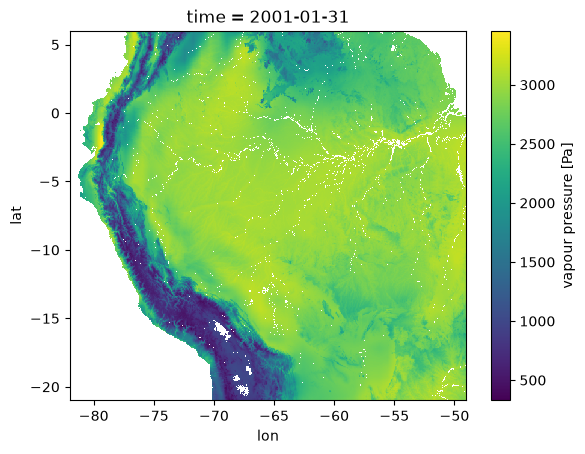

In [107]:
Pvapour_f_tavg = get_Pvapour_f_tavg(da_qair, da_psurf)
Pvapour_f_tavg.plot()

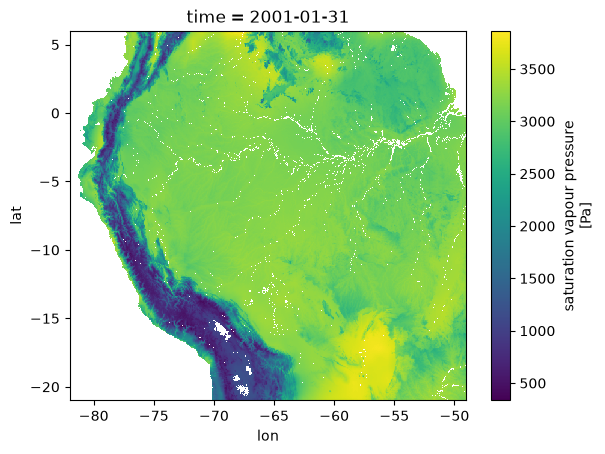

In [108]:
SatPvapour_f_tavg = get_Sat_Pvapour(ds['Tair_f_tavg'])
SatPvapour_f_tavg.plot()

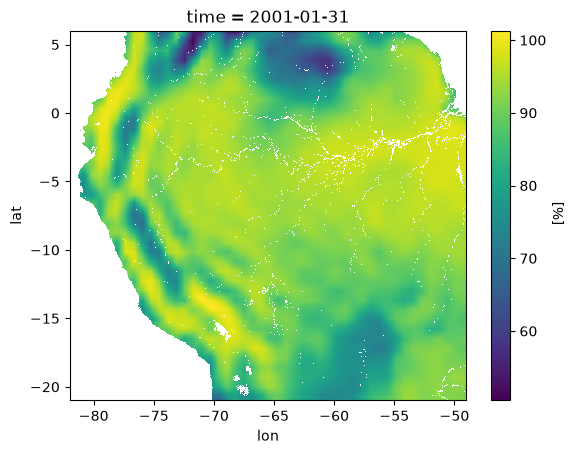

In [110]:
relative_humidity = (Pvapour_f_tavg / SatPvapour_f_tavg) * 100 
relative_humidity.attrs.update({'units' : '%'})
relative_humidity.plot()

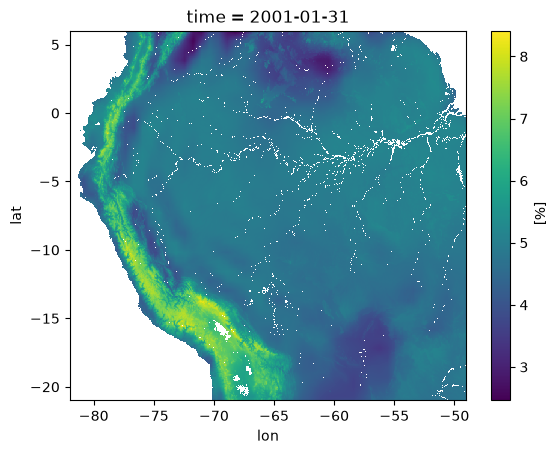

In [126]:
afi = 0.05 * relative_humidity - 0.1 *(ds['Tair_f_tavg'] - 27)
afi.plot()

In [ ]:
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=[10, 5])


---

Read Angstrom Output

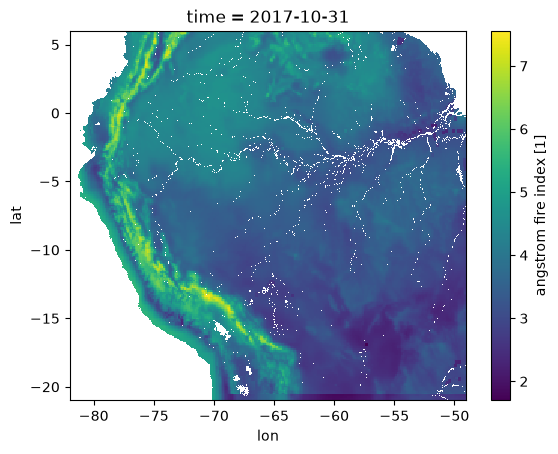

In [6]:
afi_2019_09 = xr.open_dataset(
    '/Users/kris/Downloads/angstrom_fire_output/2017_sep_angstrom/angstrom_fire_index.zarr',
    engine='zarr'
)

afi_2019_09['afi_init'].mean(dim='ensemble').isel(time = 1).plot()